In [1]:
import pandas as pd
from datetime import date, timedelta
import missingno as msno
import plotly.express as px
import sys

import random
import numpy as np

import sys

sys.path.insert(0, "../../utils")

from plots import *
from string_handling import *
from modules import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

In [2]:
REGION = 'Nord'
YEARS = range(2014, 2025)

In [3]:
datasets = []

for YEAR in YEARS:
    print(f"Reading data for Cameroon {REGION} in {YEAR}")
    # Load the dataset for the specified year
    datasets.append(pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Dataset_X_{YEAR}.csv', encoding=enc))

# Concatenate all datasets into a single DataFrame
df = pd.concat(datasets, ignore_index=True)

try:
    df.drop(['Unnamed: 0'], axis=1, inplace=True)
except KeyError:
    print("Column 'Unnamed: 0' not found in the DataFrame.")

Reading data for Cameroon Nord in 2014
Reading data for Cameroon Nord in 2015
Reading data for Cameroon Nord in 2016
Reading data for Cameroon Nord in 2017
Reading data for Cameroon Nord in 2018
Reading data for Cameroon Nord in 2019
Reading data for Cameroon Nord in 2020
Reading data for Cameroon Nord in 2021
Reading data for Cameroon Nord in 2022
Reading data for Cameroon Nord in 2023
Reading data for Cameroon Nord in 2024


In [4]:
print(df.shape)

df.head()

(19080, 76)


,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,rainfall,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,year_biovars,dt_weather_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst_min_prev_month,lst_max_prev_month,rainfall_acc_prev_month
0,2014-01,2014,1,2013,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.201207,-0.146193,-0.420008,0.146193,0.205240,-0.144522,-0.426096,0.144522,0.011465,0.018446,0.013011,0.018446,28.17,39.14,17.13,0.0047,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36.0,30,12,12,3,5,8,2013,2013-12,30.42,22.33,58.77,324.62,52.0,14.0,38.0,26.83,30.00,34.50,26.83,1888.0,489.0,2.0,108.60,1224.0,24.0,243.0,1224.0,14.19,43.33,19.2046
1,2014-01,2014,1,2013,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.220517,-0.139276,-0.423166,0.139276,0.219271,-0.138897,-0.420182,0.138897,0.013494,0.013624,0.012917,0.013624,28.79,39.04,18.53,0.0086,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36.0,30,12,12,3,5,8,2013,2013-12,29.96,20.58,58.81,379.27,50.0,15.0,35.0,25.50,31.83,34.83,25.50,1905.0,544.0,1.0,113.49,1283.0,20.0,247.0,1283.0,15.40,42.50,23.1399
2,2014-01,2014,1,2013,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.211758,-0.120636,-0.401413,0.120636,0.211377,-0.117131,-0.397288,0.117131,0.013961,0.014546,0.013695,0.014546,28.65,38.96,18.34,0.0046,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36.0,30,12,12,3,5,8,2013,2013-12,30.00,22.17,59.91,382.58,52.0,15.0,37.0,26.00,29.83,35.00,26.00,1732.0,513.0,0.0,119.68,1209.0,4.0,46.0,1209.0,15.13,42.61,4.3860
3,2014-01,2014,1,2013,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.235113,-0.096959,-0.381079,0.096959,0.234499,-0.094467,-0.381545,0.094467,0.020211,0.025244,0.024915,0.025244,27.13,37.71,16.47,0.0042,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36.0,30,12,12,1,6,7,2013,2013-12,30.04,21.42,61.19,274.24,49.0,14.0,35.0,27.33,29.00,33.83,27.33,1922.0,503.0,3.0,105.80,1210.0,24.0,271.0,1210.0,14.13,41.83,18.2167
4,2014-01,2014,1,2013,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.215577,-0.037547,-0.333702,0.037547,0.226589,-0.023893,-0.329087,0.023893,0.033854,0.036164,0.054609,0.036164,28.31,37.27,19.35,0.0000,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36.0,30,12,12,3,5,8,2013,2013-12,30.42,21.33,57.66,375.28,52.0,15.0,37.0,26.67,29.67,35.67,26.67,1725.0,471.0,0.0,117.97,1200.0,5.0,194.0,1200.0,15.03,42.72,5.3570


Text(0.5, 1.0, 'Years: 2014 - 2024')

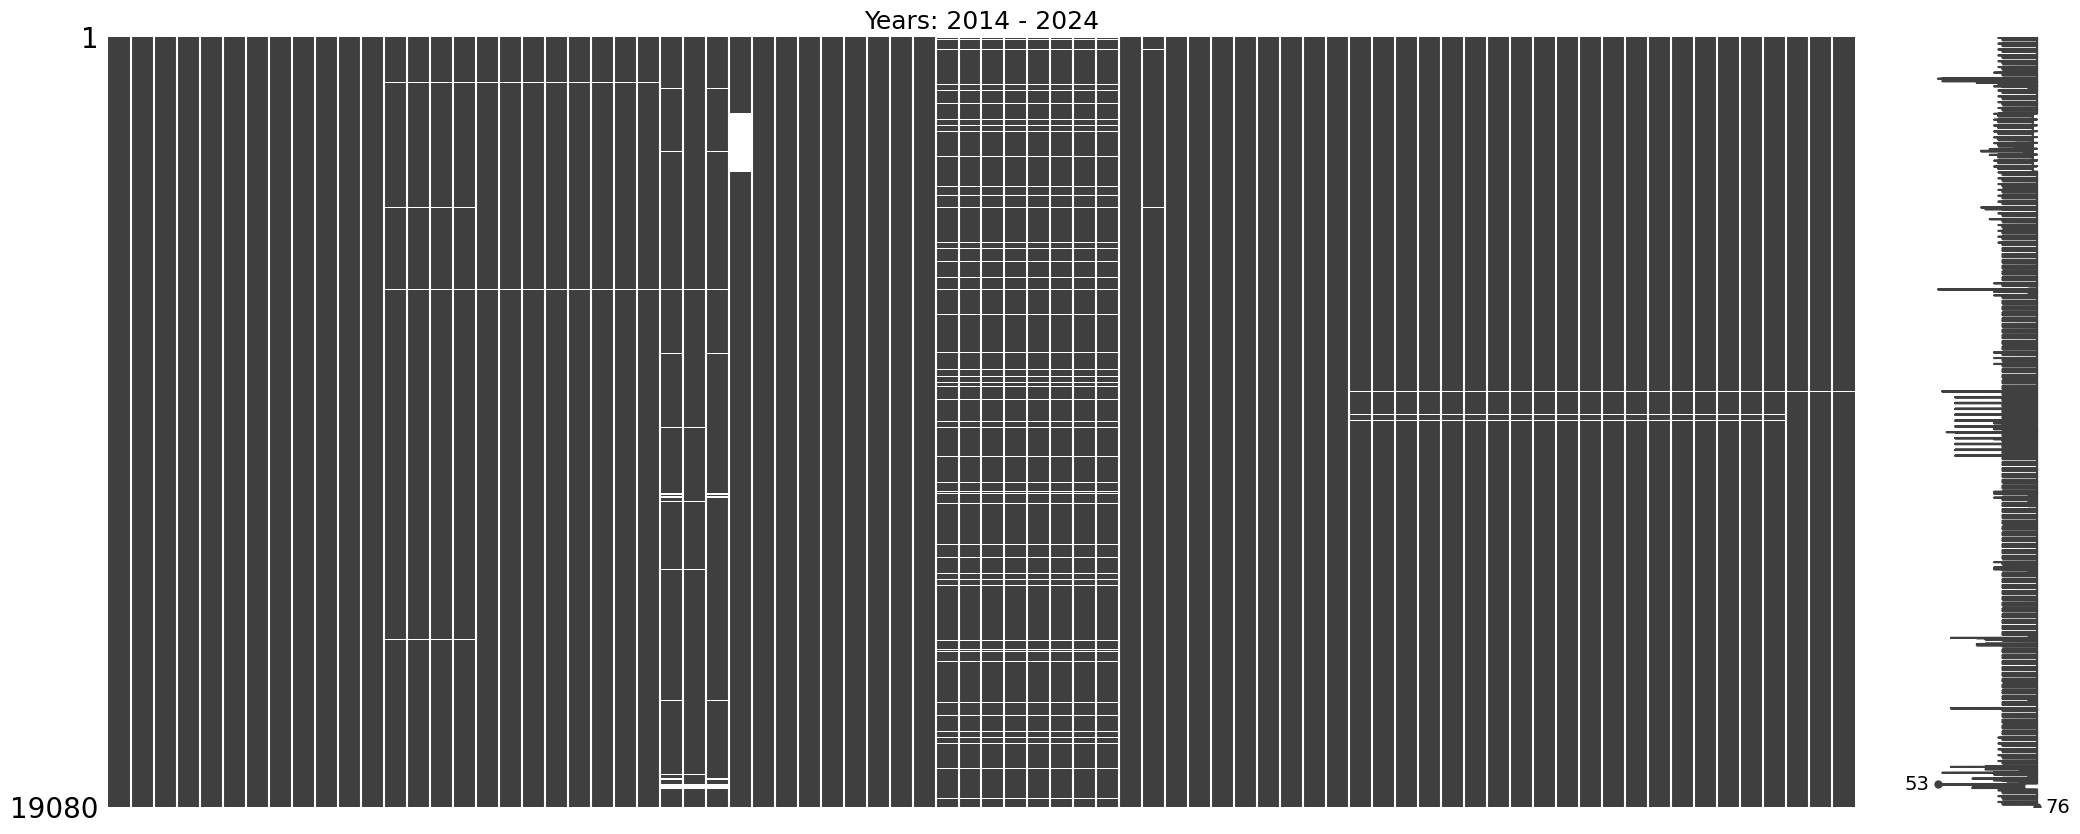

In [5]:
msno.matrix(df, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Years: {min(YEARS)} - {max(YEARS)}", fontsize=18)

In [6]:
cases_df = pd.read_csv(f'../../data/CM_MAL_cases_GID2_2015-2024_fixed.csv', encoding=enc)

try:
    cases_df.drop(['Unnamed: 0'], axis=1, inplace=True)
except KeyError:
    print("Column 'Unnamed: 0' not found in the DataFrame.")

In [7]:
print(cases_df.shape)

cases_df.head()

(50896, 20)


,dt_placement,GID0,GID2,GID3,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL
0,2015-01,extreme nord,bogo,balaza,49,43,2,94,3,12,2,17,3,12,2,17,0,0,0,0
1,2015-01,extreme nord,bogo,balda,2,5,0,7,0,0,0,0,0,0,0,0,0,0,0,0
2,2015-01,extreme nord,bogo,bogo,25,63,3,91,22,58,3,83,1,0,0,1,0,0,0,0
3,2015-01,extreme nord,bogo,borai,16,14,1,31,4,3,1,8,4,3,1,8,0,0,0,0
4,2015-01,extreme nord,bogo,guinggley,67,38,4,109,17,20,4,41,0,3,0,3,0,0,0,0


In [8]:
cases_df = cases_df[cases_df['GID0'] == 'nord'].copy()

In [9]:
df['dt_placement'] = pd.to_datetime(df['dt_placement']).dt.to_period('M')
df['dt_weather_acc'] = pd.to_datetime(df['dt_weather_acc']).dt.to_period('M')

df.rename(columns={'dt_placement': 'dt_prediction'}, inplace=True)

cases_df['dt_placement'] = pd.to_datetime(cases_df['dt_placement']).dt.to_period('M')
cases_df['dt_prediction'] = cases_df['dt_placement'] - 3

In [10]:
cases_df

,dt_placement,GID0,GID2,GID3,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL,dt_prediction
262,2015-01,nord,bibemi,adoumri,34,69,3,106,28,54,3,85,0,0,0,0,0,0,0,0,2014-10
263,2015-01,nord,bibemi,bibemi,47,33,5,85,29,8,5,42,29,8,5,42,1,0,1,2,2014-10
264,2015-01,nord,bibemi,bide,15,15,0,30,5,4,0,9,1,0,0,1,1,0,0,1,2014-10
265,2015-01,nord,bibemi,dengui,26,12,5,43,20,5,5,30,1,2,1,4,0,0,0,0,2014-10
266,2015-01,nord,bibemi,djaloumi,10,19,0,29,10,15,0,25,2,3,0,5,0,0,0,0,2014-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50891,2024-12,nord,touboro,mbeing,34,25,0,59,16,14,0,30,16,14,0,30,0,0,0,0,2024-09
50892,2024-12,nord,touboro,ngai-lara,51,46,29,126,23,30,17,70,23,30,17,70,0,1,0,1,2024-09
50893,2024-12,nord,touboro,touboro,247,330,79,656,133,150,34,317,133,150,34,317,0,0,0,0,2024-09
50894,2024-12,nord,touboro,vogzom,138,197,68,403,53,72,31,156,53,72,31,156,0,0,0,0,2024-09


In [11]:
cases_df.dt_prediction.min()

Period('2014-10', 'M')

In [12]:
cases_df.dt_prediction.max()

Period('2024-09', 'M')

In [13]:
df

,dt_prediction,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,rainfall,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,year_biovars,dt_weather_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst_min_prev_month,lst_max_prev_month,rainfall_acc_prev_month
0,2014-01,2014,1,2013,0.5,0.866,nord,benoue,bibemi,adoumri,13.770202,9.240232,0.201207,-0.146193,-0.420008,0.146193,0.205240,-0.144522,-0.426096,0.144522,0.011465,0.018446,0.013011,0.018446,28.17,39.14,17.13,0.0047,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36.0,30,12,12,3,5,8,2013,2013-12,30.42,22.33,58.77,324.62,52.0,14.0,38.0,26.83,30.00,34.50,26.83,1888.0,489.0,2.0,108.60,1224.0,24.0,243.0,1224.0,14.19,43.33,19.2046
1,2014-01,2014,1,2013,0.5,0.866,nord,benoue,bibemi,bibemi,13.949181,9.263633,0.220517,-0.139276,-0.423166,0.139276,0.219271,-0.138897,-0.420182,0.138897,0.013494,0.013624,0.012917,0.013624,28.79,39.04,18.53,0.0086,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36.0,30,12,12,3,5,8,2013,2013-12,29.96,20.58,58.81,379.27,50.0,15.0,35.0,25.50,31.83,34.83,25.50,1905.0,544.0,1.0,113.49,1283.0,20.0,247.0,1283.0,15.40,42.50,23.1399
2,2014-01,2014,1,2013,0.5,0.866,nord,benoue,bibemi,bide,13.972945,9.422292,0.211758,-0.120636,-0.401413,0.120636,0.211377,-0.117131,-0.397288,0.117131,0.013961,0.014546,0.013695,0.014546,28.65,38.96,18.34,0.0046,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36.0,30,12,12,3,5,8,2013,2013-12,30.00,22.17,59.91,382.58,52.0,15.0,37.0,26.00,29.83,35.00,26.00,1732.0,513.0,0.0,119.68,1209.0,4.0,46.0,1209.0,15.13,42.61,4.3860
3,2014-01,2014,1,2013,0.5,0.866,nord,benoue,bibemi,dengui,13.642496,9.235656,0.235113,-0.096959,-0.381079,0.096959,0.234499,-0.094467,-0.381545,0.094467,0.020211,0.025244,0.024915,0.025244,27.13,37.71,16.47,0.0042,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36.0,30,12,12,1,6,7,2013,2013-12,30.04,21.42,61.19,274.24,49.0,14.0,35.0,27.33,29.00,33.83,27.33,1922.0,503.0,3.0,105.80,1210.0,24.0,271.0,1210.0,14.13,41.83,18.2167
4,2014-01,2014,1,2013,0.5,0.866,nord,benoue,bibemi,djaloumi,13.994667,9.585190,0.215577,-0.037547,-0.333702,0.037547,0.226589,-0.023893,-0.329087,0.023893,0.033854,0.036164,0.054609,0.036164,28.31,37.27,19.35,0.0000,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36.0,30,12,12,3,5,8,2013,2013-12,30.42,21.33,57.66,375.28,52.0,15.0,37.0,26.67,29.67,35.67,26.67,1725.0,471.0,0.0,117.97,1200.0,5.0,194.0,1200.0,15.03,42.72,5.3570
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19075,2024-12,2024,12,2023,0.0,1.000,nord,mayo-rey,touboro,mbeing,15.001895,7.650008,0.404566,0.004045,-0.360921,-0.004045,0.407666,0.007945,-0.362101,-0.007945,0.026467,0.029746,0.018991,0.029746,22.13,27.18,17.10,0.0086,125988.49,1351.46,5.49,165.60,710.63,180.16,0.0,416.45,9674.69,975.21,6.24,51.83,161.28,6.21,0.0,3164.67,22,20.0,20,9,9,4,4,4,2023,2024-11,25.75,15.00,50.00,291.94,44.0,14.0,30.0,23.33,25.17,29.67,23.33,2746.0,582.0,0.0,91.49,1488.0,0.0,205.0,1488.0,15.99,29.07,0.0257
19076,2024-12,2024,12,2023

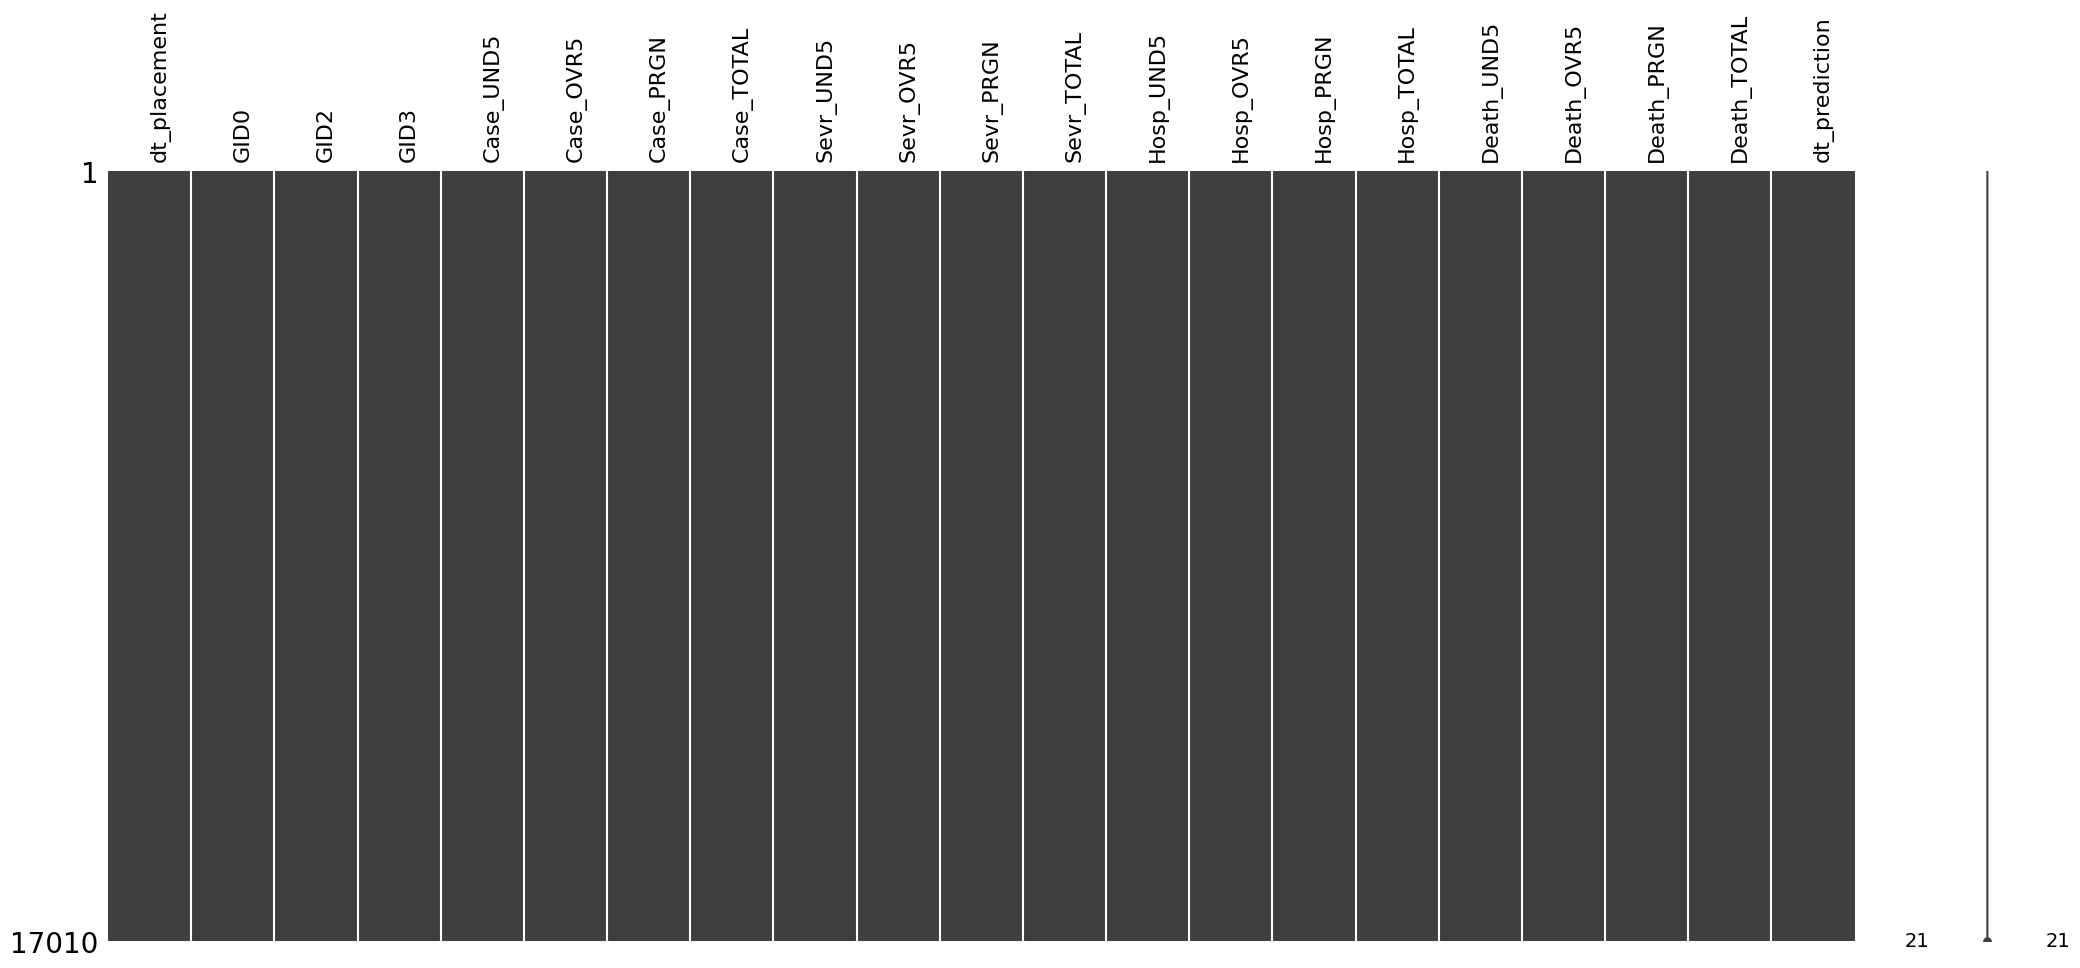

In [14]:
msno.matrix(cases_df, label_rotation=90)
ax = plt.gca()

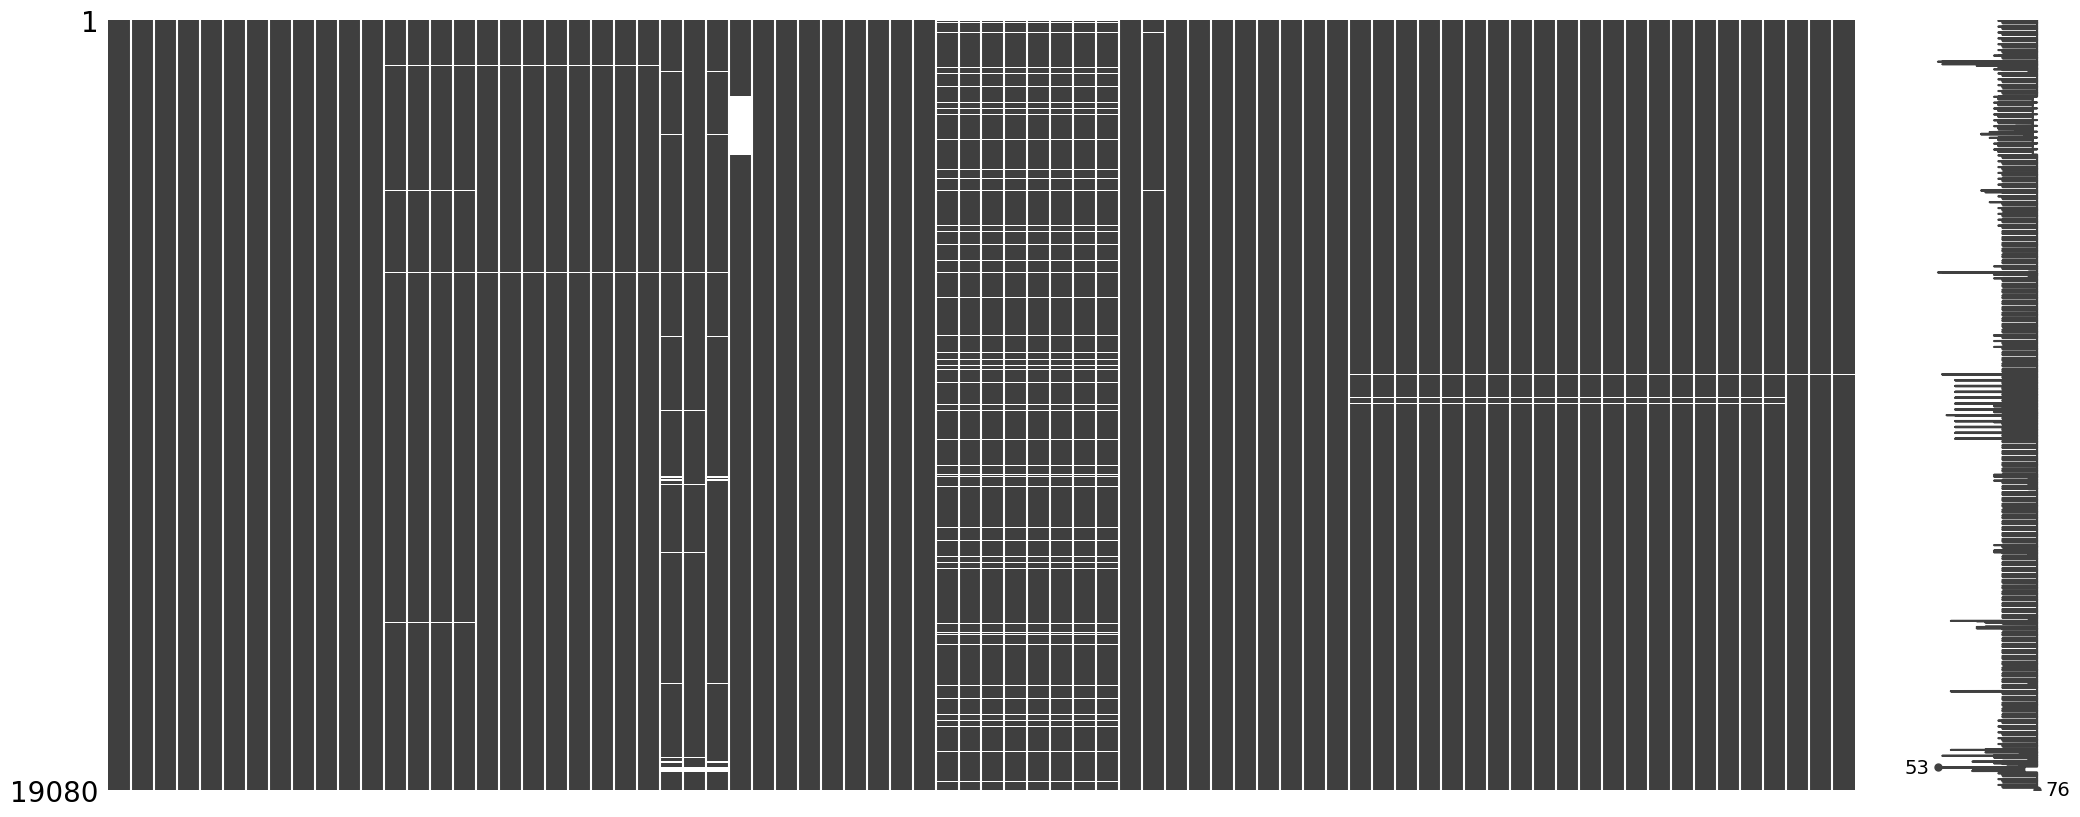

In [15]:
msno.matrix(df, label_rotation=90)
ax = plt.gca()

In [16]:
df['location'] = list(zip(df['GID0'], df['GID2'], df['GID3']))
cases_df['location'] = list(zip(cases_df['GID0'], cases_df['GID2'], cases_df['GID3']))

all_locations_df = set(df['location'])
all_locations_df_cases = set(cases_df['location'])

all_exist = all_locations_df_cases.issubset(all_locations_df)
print("All locations from frame2 (cases) exist in frame1 (input):", all_exist)

missing_locations = all_locations_df_cases - all_locations_df
sorted(missing_locations)

All locations from frame2 (cases) exist in frame1 (input): True


[]

In [17]:
cases_df.columns

Index(['dt_placement', 'GID0', 'GID2', 'GID3', 'Case_UND5', 'Case_OVR5',
       'Case_PRGN', 'Case_TOTAL', 'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN',
       'Sevr_TOTAL', 'Hosp_UND5', 'Hosp_OVR5', 'Hosp_PRGN', 'Hosp_TOTAL',
       'Death_UND5', 'Death_OVR5', 'Death_PRGN', 'Death_TOTAL',
       'dt_prediction', 'location'],
      dtype='object')

In [18]:
case_columns = ['Case_UND5', 'Case_OVR5', 'Case_PRGN', 'Case_TOTAL',
                'Sevr_UND5', 'Sevr_OVR5', 'Sevr_PRGN', 'Sevr_TOTAL',
                'Hosp_UND5', 'Hosp_OVR5', 'Hosp_PRGN', 'Hosp_TOTAL', 
                'Death_UND5', 'Death_OVR5', 'Death_PRGN', 'Death_TOTAL' 
                ]

cases_to_merge = cases_df[['location', 'dt_placement', 'dt_prediction'] + case_columns].copy()

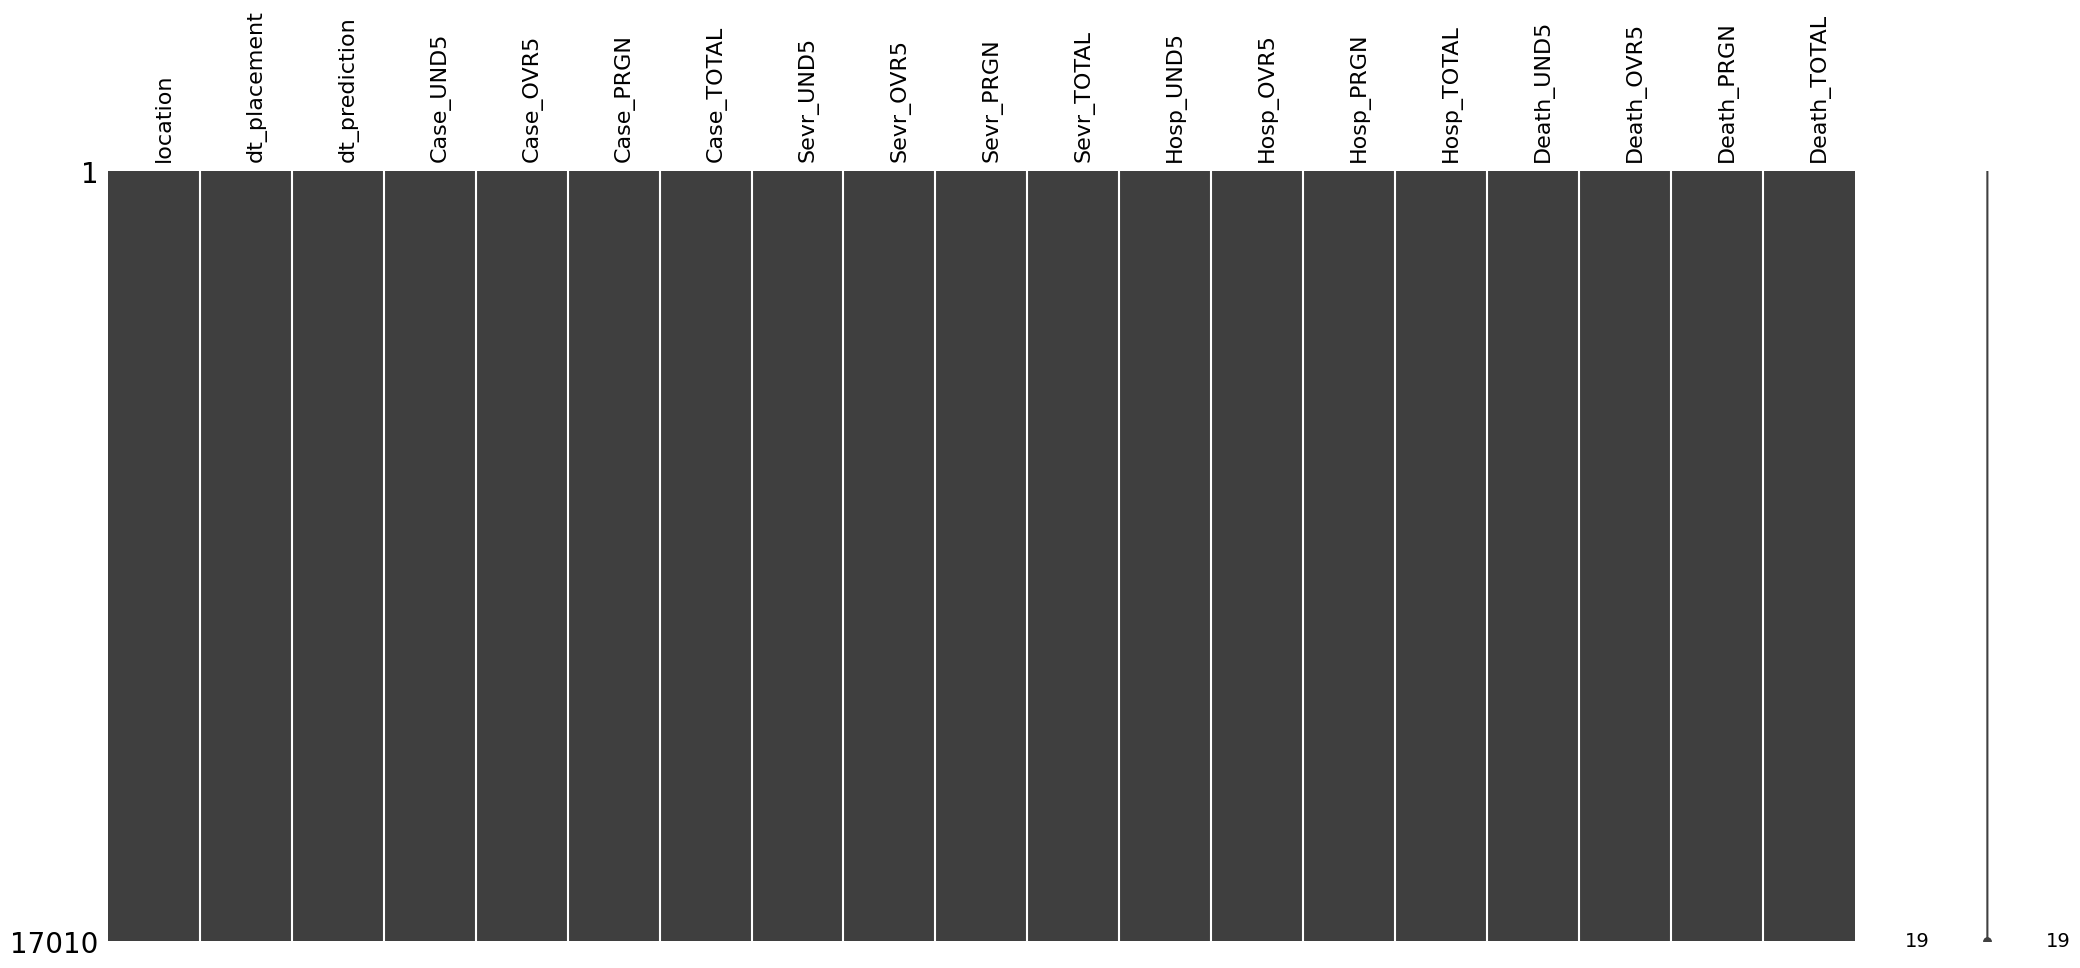

In [19]:
msno.matrix(cases_to_merge, label_rotation=90)
ax = plt.gca()

In [20]:
dataset_final = pd.merge(df, cases_to_merge, on=['location', 'dt_prediction'], how='left')

In [21]:
len(dataset_final.columns.to_list())


94

In [22]:
rearranged_columns = ['location','GID0','GID1','GID2','GID3','x','y',
 'dt_prediction','year', 'month','month_sin','month_cos','dt_placement','dt_weather_acc', 'year_biovars', 'year_lc',
 'ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std',
 'lst','lst_day','lst_night','lst_min_prev_month','lst_max_prev_month',
 'rainfall','rainfall_acc_prev_month',
 'distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m',
 'distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std',
 'lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5',
 'bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19',
 'Case_UND5','Case_OVR5','Case_PRGN','Case_TOTAL',
 'Sevr_UND5','Sevr_OVR5','Sevr_PRGN','Sevr_TOTAL',
 'Hosp_UND5','Hosp_OVR5','Hosp_PRGN','Hosp_TOTAL',
 'Death_UND5','Death_OVR5','Death_PRGN','Death_TOTAL']

In [23]:
dataset_final= dataset_final[rearranged_columns].copy()

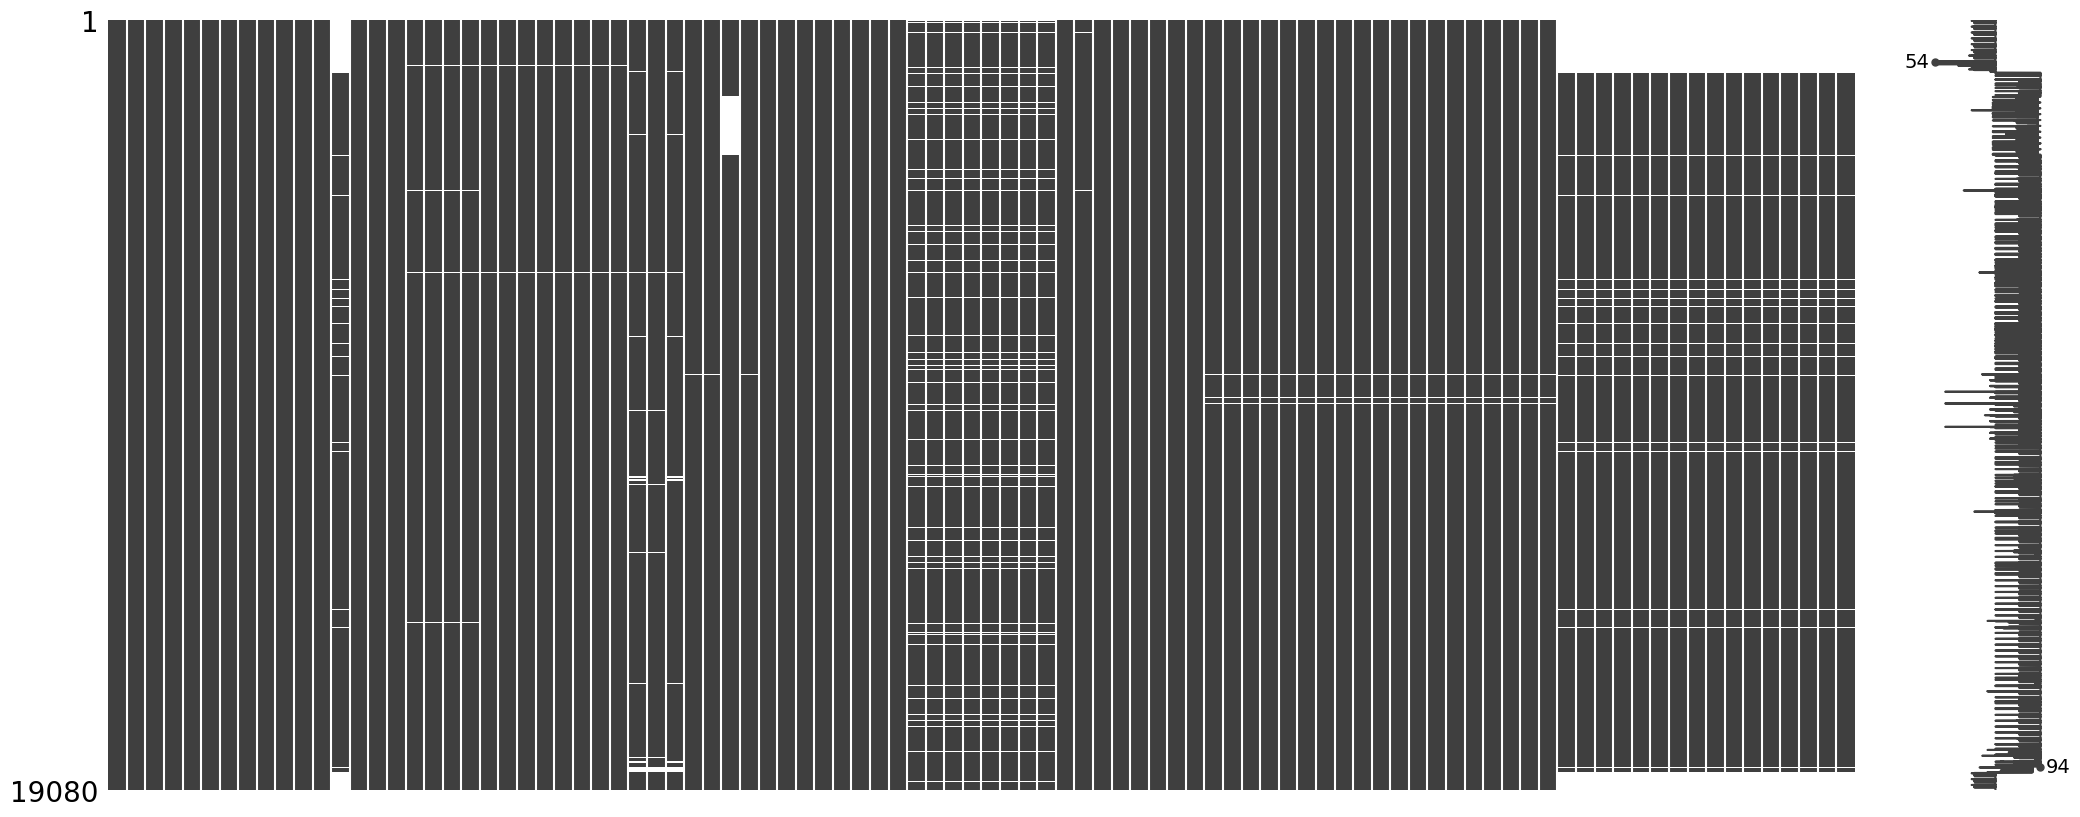

In [24]:
msno.matrix(dataset_final, label_rotation=90)
ax = plt.gca()

In [25]:
dataset_final.head()

,location,GID0,GID1,GID2,GID3,x,y,dt_prediction,year,month,month_sin,month_cos,dt_placement,dt_weather_acc,year_biovars,year_lc,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_min_prev_month,lst_max_prev_month,rainfall,rainfall_acc_prev_month,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL
0,"(nord, bibemi, adoumri)",nord,benoue,bibemi,adoumri,13.770202,9.240232,2014-01,2014,1,0.5,0.866,NaT,2013-12,2013,2013,0.201207,-0.146193,-0.420008,0.146193,0.205240,-0.144522,-0.426096,0.144522,0.011465,0.018446,0.013011,0.018446,28.17,39.14,17.13,14.19,43.33,0.0047,19.2046,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36.0,30,12,12,3,5,8,30.42,22.33,58.77,324.62,52.0,14.0,38.0,26.83,30.00,34.50,26.83,1888.0,489.0,2.0,108.60,1224.0,24.0,243.0,1224.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"(nord, bibemi, bibemi)",nord,benoue,bibemi,bibemi,13.949181,9.263633,2014-01,2014,1,0.5,0.866,NaT,2013-12,2013,2013,0.220517,-0.139276,-0.423166,0.139276,0.219271,-0.138897,-0.420182,0.138897,0.013494,0.013624,0.012917,0.013624,28.79,39.04,18.53,15.40,42.50,0.0086,23.1399,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36.0,30,12,12,3,5,8,29.96,20.58,58.81,379.27,50.0,15.0,35.0,25.50,31.83,34.83,25.50,1905.0,544.0,1.0,113.49,1283.0,20.0,247.0,1283.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"(nord, bibemi, bide)",nord,benoue,bibemi,bide,13.972945,9.422292,2014-01,2014,1,0.5,0.866,NaT,2013-12,2013,2013,0.211758,-0.120636,-0.401413,0.120636,0.211377,-0.117131,-0.397288,0.117131,0.013961,0.014546,0.013695,0.014546,28.65,38.96,18.34,15.13,42.61,0.0046,4.3860,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36.0,30,12,12,3,5,8,30.00,22.17,59.91,382.58,52.0,15.0,37.0,26.00,29.83,35.00,26.00,1732.0,513.0,0.0,119.68,1209.0,4.0,46.0,1209.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"(nord, bibemi, dengui)",nord,benoue,bibemi,dengui,13.642496,9.235656,2014-01,2014,1,0.5,0.866,NaT,2013-12,2013,2013,0.235113,-0.096959,-0.381079,0.096959,0.234499,-0.094467,-0.381545,0.094467,0.020211,0.025244,0.024915,0.025244,27.13,37.71,16.47,14.13,41.83,0.0042,18.2167,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36.0,30,12,12,1,6,7,30.04,21.42,61.19,274.24,49.0,14.0,35.0,27.33,29.00,33.83,27.33,1922.0,503.0,3.0,105.80,1210.0,24.0,271.0,1210.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"(nord, bibemi, djaloumi)",nord,benoue,bibemi,djaloumi,13.994667,9.585190,2014-01,2014,1,0.5,0.866,NaT,2013-12,2013,2013,0.215577,-0.037547,-0.333702,0.037547,0.226589,-0.023893,-0.329087,0.023893,0.033854,0.036164,0.054609,0.036164,28.31,37.27,19.35,15.03,42.72,0.0000,5.3570,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36.0,30,12,12,3,5,8,30.42,21.33,57.66,375.28,52.0,15.0,37.0,26.67,29.67,35.67,26.67,1725.0,471.0,0.0,117.97,1200.0,5.0,194.0,1200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
dataset_final

,location,GID0,GID1,GID2,GID3,x,y,dt_prediction,year,month,month_sin,month_cos,dt_placement,dt_weather_acc,year_biovars,year_lc,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_min_prev_month,lst_max_prev_month,rainfall,rainfall_acc_prev_month,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL
0,"(nord, bibemi, adoumri)",nord,benoue,bibemi,adoumri,13.770202,9.240232,2014-01,2014,1,0.5,0.866,NaT,2013-12,2013,2013,0.201207,-0.146193,-0.420008,0.146193,0.205240,-0.144522,-0.426096,0.144522,0.011465,0.018446,0.013011,0.018446,28.17,39.14,17.13,14.19,43.33,0.0047,19.2046,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36.0,30,12,12,3,5,8,30.42,22.33,58.77,324.62,52.0,14.0,38.0,26.83,30.00,34.50,26.83,1888.0,489.0,2.0,108.60,1224.0,24.0,243.0,1224.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"(nord, bibemi, bibemi)",nord,benoue,bibemi,bibemi,13.949181,9.263633,2014-01,2014,1,0.5,0.866,NaT,2013-12,2013,2013,0.220517,-0.139276,-0.423166,0.139276,0.219271,-0.138897,-0.420182,0.138897,0.013494,0.013624,0.012917,0.013624,28.79,39.04,18.53,15.40,42.50,0.0086,23.1399,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36.0,30,12,12,3,5,8,29.96,20.58,58.81,379.27,50.0,15.0,35.0,25.50,31.83,34.83,25.50,1905.0,544.0,1.0,113.49,1283.0,20.0,247.0,1283.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"(nord, bibemi, bide)",nord,benoue,bibemi,bide,13.972945,9.422292,2014-01,2014,1,0.5,0.866,NaT,2013-12,2013,2013,0.211758,-0.120636,-0.401413,0.120636,0.211377,-0.117131,-0.397288,0.117131,0.013961,0.014546,0.013695,0.014546,28.65,38.96,18.34,15.13,42.61,0.0046,4.3860,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36.0,30,12,12,3,5,8,30.00,22.17,59.91,382.58,52.0,15.0,37.0,26.00,29.83,35.00,26.00,1732.0,513.0,0.0,119.68,1209.0,4.0,46.0,1209.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"(nord, bibemi, dengui)",nord,benoue,bibemi,dengui,13.642496,9.235656,2014-01,2014,1,0.5,0.866,NaT,2013-12,2013,2013,0.235113,-0.096959,-0.381079,0.096959,0.234499,-0.094467,-0.381545,0.094467,0.020211,0.025244,0.024915,0.025244,27.13,37.71,16.47,14.13,41.83,0.0042,18.2167,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36.0,30,12,12,1,6,7,30.04,21.42,61.19,274.24,49.0,14.0,35.0,27.33,29.00,33.83,27.33,1922.0,503.0,3.0,105.80,1210.0,24.0,271.0,1210.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"(nord, bibemi, djaloumi)",nord,benoue,bibemi,djaloumi,13.994667,9.585190,2014-01,2014,1,0.5,0.866,NaT,2013-12,2013,2013,0.215577,-0.037547,-0.333702,0.037547,0.226589,-0.023893,-0.329087,0.023893,0.033854,0.036164,0.054609,0.036164,28.31,37.27,19.35,15.03,42.72,0.0000,5.3570,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36.0,30,12,12,3,5,8,30.42,21.33,57.66,375.28,52.0,15.0,37.0,26.67,29.67,35.67,26.67,1725.0,471.0,0.0,117.97,1200.0,5.0,194.0,1200.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [27]:
print(cases_df.dt_prediction.min())
print(cases_df.dt_prediction.max())

2014-10
2024-09


In [28]:
dataset_final = dataset_final[(dataset_final['dt_prediction'] >= pd.Period(cases_df.dt_prediction.min(), freq='M')) & 
                              (dataset_final['dt_prediction'] <= pd.Period(cases_df.dt_prediction.max(), freq='M'))].copy()

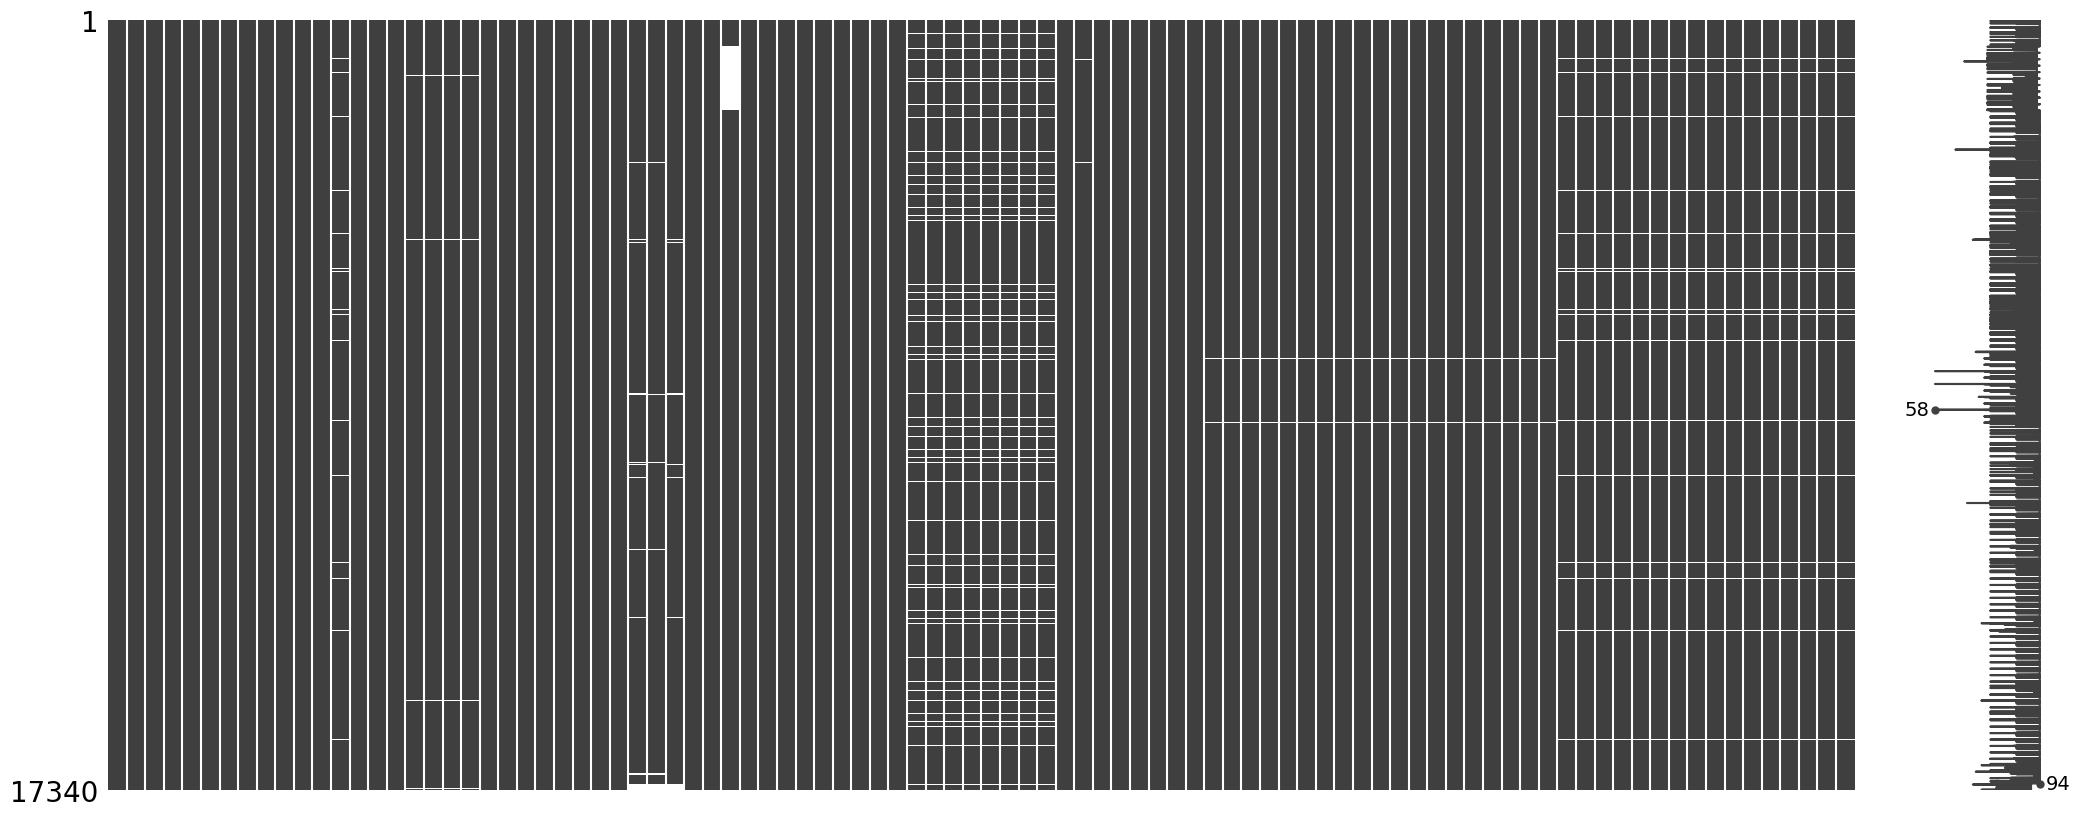

In [29]:
msno.matrix(dataset_final, label_rotation=90)
ax = plt.gca()

In [30]:
dataset_final[case_columns] = dataset_final[case_columns].fillna(0)

In [31]:
dataset_final[case_columns] = dataset_final[case_columns].apply(lambda col: pd.to_numeric(col, errors='coerce').astype('Int64'))
dataset_final.drop(columns=['location'], inplace=True)
dataset_final.rename(columns={'dt_placement': 'dt_recorded_cases'}, inplace=True)
dataset_final.reset_index(drop=True, inplace=True)
for col in dataset_final.select_dtypes(include='float').columns:
    if dataset_final[col].dropna().apply(float.is_integer).all():
        dataset_final[col] = dataset_final[col].astype('Int64')

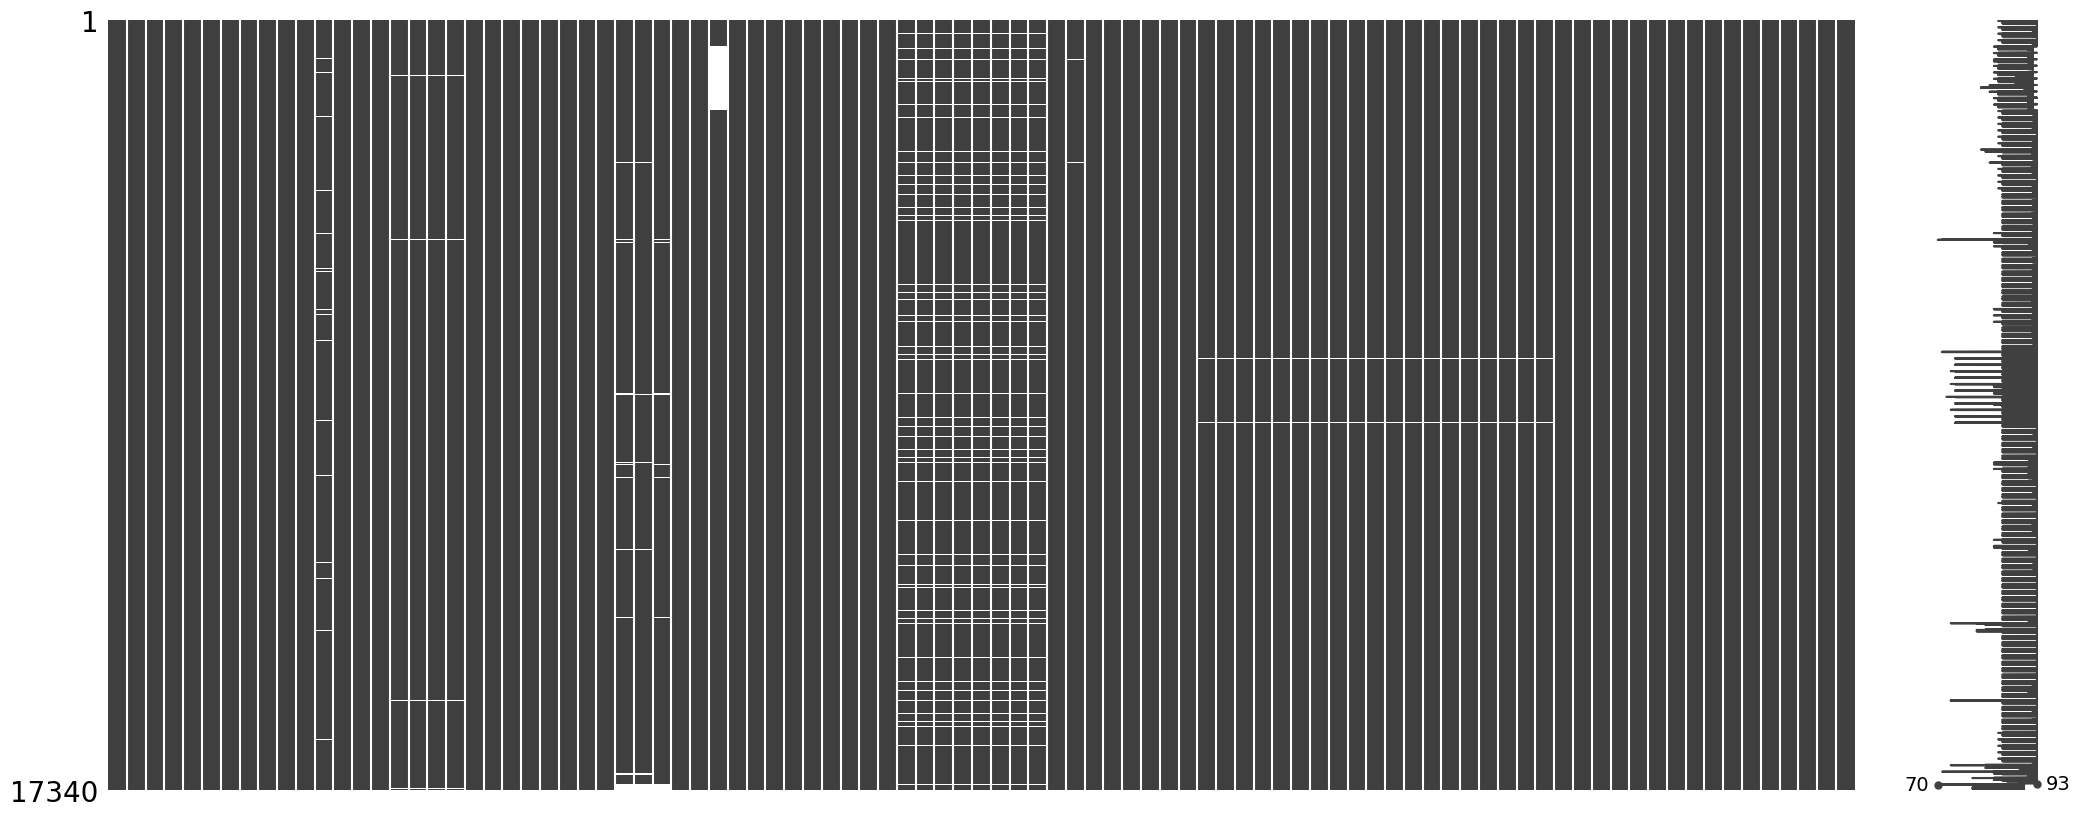

In [32]:
msno.matrix(dataset_final, label_rotation=90)
ax = plt.gca()

In [33]:
dataset_final

,GID0,GID1,GID2,GID3,x,y,dt_prediction,year,month,month_sin,month_cos,dt_recorded_cases,dt_weather_acc,year_biovars,year_lc,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_min_prev_month,lst_max_prev_month,rainfall,rainfall_acc_prev_month,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL
0,nord,benoue,bibemi,adoumri,13.770202,9.240232,2014-10,2014,10,-0.866,0.5,2015-01,2014-09,2013,2013,0.542311,0.148177,-0.365296,-0.148177,0.536385,0.145708,-0.362984,-0.145708,0.027947,0.023841,0.018223,0.023841,28.05,32.91,23.20,23.40,30.90,5.5567,479.8346,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36,30,12,12,3,5,8,30.42,22.33,58.77,324.62,52,14,38,26.83,30.00,34.50,26.83,1888,489,2,108.60,1224,24,243,1224,34,69,3,106,28,54,3,85,0,0,0,0,0,0,0,0
1,nord,benoue,bibemi,bibemi,13.949181,9.263633,2014-10,2014,10,-0.866,0.5,2015-01,2014-09,2013,2013,0.499024,0.112709,-0.351063,-0.112709,0.495997,0.114184,-0.346613,-0.114184,0.027845,0.024597,0.017377,0.024597,27.83,32.62,23.05,18.51,30.41,5.6123,519.4497,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36,30,12,12,3,5,8,29.96,20.58,58.81,379.27,50,15,35,25.50,31.83,34.83,25.50,1905,544,1,113.49,1283,20,247,1283,47,33,5,85,29,8,5,42,29,8,5,42,1,0,1,2
2,nord,benoue,bibemi,bide,13.972945,9.422292,2014-10,2014,10,-0.866,0.5,2015-01,2014-09,2013,2013,0.491692,0.119406,-0.338767,-0.119406,0.490872,0.121937,-0.335555,-0.121937,0.026591,0.023810,0.015130,0.023810,28.23,33.41,23.05,23.08,30.92,5.3087,474.4609,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36,30,12,12,3,5,8,30.00,22.17,59.91,382.58,52,15,37,26.00,29.83,35.00,26.00,1732,513,0,119.68,1209,4,46,1209,15,15,0,30,5,4,0,9,1,0,0,1,1,0,0,1
3,nord,benoue,bibemi,dengui,13.642496,9.235656,2014-10,2014,10,-0.866,0.5,2015-01,2014-09,2013,2013,0.511243,0.171523,-0.300408,-0.171523,0.497053,0.159206,-0.301752,-0.159206,0.045405,0.047888,0.047695,0.047888,28.56,32.84,23.99,18.72,31.63,6.0290,482.6476,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36,30,12,12,1,6,7,30.04,21.42,61.19,274.24,49,14,35,27.33,29.00,33.83,27.33,1922,503,3,105.80,1210,24,271,1210,26,12,5,43,20,5,5,30,1,2,1,4,0,0,0,0
4,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2014-10,2014,10,-0.866,0.5,2015-01,2014-09,2013,2013,0.505574,0.198941,-0.280563,-0.198941,0.464128,0.213616,-0.221795,-0.213616,0.048263,0.028936,0.056152,0.028936,28.32,33.09,23.54,23.38,37.73,5.2490,497.3253,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36,30,12,12,3,5,8,30.42,21.33,57.66,375.28,52,15,37,26.67,29.67,35.67,26.67,1725,471,0,117.97,1200,5,194,1200,10,19,0,29,10,15,0,25,2,3,0,5,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17335,nord,mayo-rey,touboro,mbeing,15.001895,7.650008,2024-09,2024,9,-1.000,0.0,2024-12,2024-08,2023,2023,0.444202,0.246985,-0.3

In [34]:
dataset_final.dropna(subset=["dt_recorded_cases"], inplace=True)

In [35]:
dataset_final

,GID0,GID1,GID2,GID3,x,y,dt_prediction,year,month,month_sin,month_cos,dt_recorded_cases,dt_weather_acc,year_biovars,year_lc,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_min_prev_month,lst_max_prev_month,rainfall,rainfall_acc_prev_month,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,Case_UND5,Case_OVR5,Case_PRGN,Case_TOTAL,Sevr_UND5,Sevr_OVR5,Sevr_PRGN,Sevr_TOTAL,Hosp_UND5,Hosp_OVR5,Hosp_PRGN,Hosp_TOTAL,Death_UND5,Death_OVR5,Death_PRGN,Death_TOTAL
0,nord,benoue,bibemi,adoumri,13.770202,9.240232,2014-10,2014,10,-0.866,0.5,2015-01,2014-09,2013,2013,0.542311,0.148177,-0.365296,-0.148177,0.536385,0.145708,-0.362984,-0.145708,0.027947,0.023841,0.018223,0.023841,28.05,32.91,23.20,23.40,30.90,5.5567,479.8346,11525.50,1189.57,3.20,176.56,234.75,181.29,0.0,4.12,2812.42,750.98,1.79,48.90,24.03,1.21,0.0,5.97,31,36,30,12,12,3,5,8,30.42,22.33,58.77,324.62,52,14,38,26.83,30.00,34.50,26.83,1888,489,2,108.60,1224,24,243,1224,34,69,3,106,28,54,3,85,0,0,0,0,0,0,0,0
1,nord,benoue,bibemi,bibemi,13.949181,9.263633,2014-10,2014,10,-0.866,0.5,2015-01,2014-09,2013,2013,0.499024,0.112709,-0.351063,-0.112709,0.495997,0.114184,-0.346613,-0.114184,0.027845,0.024597,0.017377,0.024597,27.83,32.62,23.05,18.51,30.41,5.6123,519.4497,27643.51,1357.07,2.87,173.78,293.25,180.81,0.0,93.00,6064.19,931.67,1.64,38.30,43.86,1.30,0.0,459.01,31,36,30,12,12,3,5,8,29.96,20.58,58.81,379.27,50,15,35,25.50,31.83,34.83,25.50,1905,544,1,113.49,1283,20,247,1283,47,33,5,85,29,8,5,42,29,8,5,42,1,0,1,2
2,nord,benoue,bibemi,bide,13.972945,9.422292,2014-10,2014,10,-0.866,0.5,2015-01,2014-09,2013,2013,0.491692,0.119406,-0.338767,-0.119406,0.490872,0.121937,-0.335555,-0.121937,0.026591,0.023810,0.015130,0.023810,28.23,33.41,23.05,23.08,30.92,5.3087,474.4609,22660.82,1318.02,2.60,168.65,304.32,180.30,0.0,93.49,5555.85,719.27,1.24,31.22,20.07,1.64,0.0,330.45,31,36,30,12,12,3,5,8,30.00,22.17,59.91,382.58,52,15,37,26.00,29.83,35.00,26.00,1732,513,0,119.68,1209,4,46,1209,15,15,0,30,5,4,0,9,1,0,0,1,1,0,0,1
3,nord,benoue,bibemi,dengui,13.642496,9.235656,2014-10,2014,10,-0.866,0.5,2015-01,2014-09,2013,2013,0.511243,0.171523,-0.300408,-0.171523,0.497053,0.159206,-0.301752,-0.159206,0.045405,0.047888,0.047695,0.047888,28.56,32.84,23.99,18.72,31.63,6.0290,482.6476,6789.43,1430.32,2.18,167.13,200.16,180.52,0.0,5.11,4263.62,736.59,1.17,24.83,14.39,1.04,0.0,7.22,31,36,30,12,12,1,6,7,30.04,21.42,61.19,274.24,49,14,35,27.33,29.00,33.83,27.33,1922,503,3,105.80,1210,24,271,1210,26,12,5,43,20,5,5,30,1,2,1,4,0,0,0,0
4,nord,benoue,bibemi,djaloumi,13.994667,9.585190,2014-10,2014,10,-0.866,0.5,2015-01,2014-09,2013,2013,0.505574,0.198941,-0.280563,-0.198941,0.464128,0.213616,-0.221795,-0.213616,0.048263,0.028936,0.056152,0.028936,28.32,33.09,23.54,23.38,37.73,5.2490,497.3253,5443.51,2018.69,9.33,194.84,332.21,175.00,0.0,6.19,4805.14,451.44,9.71,47.64,77.27,7.15,0.0,7.46,31,36,30,12,12,3,5,8,30.42,21.33,57.66,375.28,52,15,37,26.67,29.67,35.67,26.67,1725,471,0,117.97,1200,5,194,1200,10,19,0,29,10,15,0,25,2,3,0,5,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17335,nord,mayo-rey,touboro,mbeing,15.001895,7.650008,2024-09,2024,9,-1.000,0.0,2024-12,2024-08,2023,2023,0.444202,0.246985,-0.3

In [36]:
dataset_final.to_csv(f'../../data/{REGION}/CM_{REGION}_Dataset_2015-2024.csv', index=False,  encoding=enc)